# TT-13 — LASSO REGRESSION (L1)

## 0. Import thư viện

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LassoCV, Lasso, RidgeCV, lasso_path
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

RNG_SEED = 42
%matplotlib inline

## 1. Nạp dữ liệu & mở rộng thành 200 cột (10 thật + 190 nhiễu)

Thiết kế này cho phép **chấm điểm khách quan**: Lasso có tìm lại đúng 10 cột gốc và loại
190 cột nhiễu không? Đây là bài tập hiếm hoi có đáp án đúng biết trước.

In [2]:
X, y = load_diabetes(return_X_y=True, as_frame=True)
BIEN_THAT = list(X.columns)

rng = np.random.default_rng(RNG_SEED)
nhieu = pd.DataFrame(
    rng.normal(size=(len(X), 190)),
    columns=[f"chi_so_nhieu_{i:03d}" for i in range(190)],
)
X_full = pd.concat([X, nhieu], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=RNG_SEED
)

print(f"Dữ liệu: {X_full.shape[0]} dòng x {X_full.shape[1]} cột "
      f"({len(BIEN_THAT)} biến thật + 190 biến nhiễu)")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
X_full.head()

Dữ liệu: 442 dòng x 200 cột (10 biến thật + 190 biến nhiễu)
Train: (353, 200), Test: (89, 200)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,...,chi_so_nhieu_180,chi_so_nhieu_181,chi_so_nhieu_182,chi_so_nhieu_183,chi_so_nhieu_184,chi_so_nhieu_185,chi_so_nhieu_186,chi_so_nhieu_187,chi_so_nhieu_188,chi_so_nhieu_189
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,...,1.306002,0.219383,-0.410927,1.106289,0.428756,1.535756,0.183234,-1.224469,-1.368159,1.650928
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,...,0.011426,1.328961,0.856794,0.841820,0.554117,2.327653,-0.205162,-2.003522,1.604254,-0.457699
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,...,-0.070680,0.334295,0.051142,-0.765535,0.900185,0.739413,-0.159648,-0.652916,0.548428,0.187974
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,...,0.011451,-0.299265,-1.015068,2.048756,1.785168,1.136049,-0.920850,0.855019,0.639626,0.442546
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,...,0.211610,0.886394,0.490767,1.200306,0.289359,-0.355698,0.335841,-2.930594,0.382886,-3.648413


## 2. Baseline: Linear Regression trên 200 cột → quan sát overfit

In [3]:
scaler_base = StandardScaler()
Xtr_s = scaler_base.fit_transform(X_train)
Xte_s = scaler_base.transform(X_test)

lin = LinearRegression()
lin.fit(Xtr_s, y_train)
rmse_lin_train = mean_squared_error(y_train, lin.predict(Xtr_s)) ** 0.5
rmse_lin_test = mean_squared_error(y_test, lin.predict(Xte_s)) ** 0.5

print(f"RMSE train = {rmse_lin_train:.2f}")
print(f"RMSE test  = {rmse_lin_test:.2f}  <- lớn hơn nhiều so với train => OVERFIT rõ rệt")

RMSE train = 33.99
RMSE test  = 84.78  <- lớn hơn nhiều so với train => OVERFIT rõ rệt


## 3. LassoCV dò alpha (5-fold CV)

In [4]:
pipe_lasso = Pipeline([
    ("scale", StandardScaler()),
    ("lasso", LassoCV(alphas=np.logspace(-4, 1, 100), cv=5,
                       max_iter=50000, random_state=RNG_SEED)),
])
pipe_lasso.fit(X_train, y_train)

lasso_model = pipe_lasso["lasso"]
alpha_toi_uu = lasso_model.alpha_
he_so = lasso_model.coef_
so_bien_giu = int((he_so != 0).sum())

rmse_lasso_train = mean_squared_error(y_train, pipe_lasso.predict(X_train)) ** 0.5
rmse_lasso_test = mean_squared_error(y_test, pipe_lasso.predict(X_test)) ** 0.5

print(f"alpha tối ưu (CV) = {alpha_toi_uu:.5f}")
print(f"Lasso giữ lại {so_bien_giu}/200 biến")
print(f"RMSE train = {rmse_lasso_train:.2f}")
print(f"RMSE test  = {rmse_lasso_test:.2f}")

alpha tối ưu (CV) = 7.92483
Lasso giữ lại 5/200 biến
RMSE train = 56.28
RMSE test  = 53.73


## 4. ⭐ Chấm điểm chọn biến

- Bao nhiêu trong 10 biến THẬT được giữ? (recall chọn biến)
- Bao nhiêu biến nhiễu bị giữ nhầm? (false positive)

In [5]:
ten_cot = X_full.columns
bien_duoc_chon = set(ten_cot[he_so != 0])

that_giu = sorted(bien_duoc_chon & set(BIEN_THAT))
that_bo = sorted(set(BIEN_THAT) - bien_duoc_chon)
nhieu_giu_nham = sorted(bien_duoc_chon - set(BIEN_THAT))

print(f"Biến THẬT được giữ ({len(that_giu)}/10): {that_giu}")
print(f"Biến THẬT bị bỏ    ({len(that_bo)}/10): {that_bo}")
print(f"Biến NHIỄU bị giữ nhầm ({len(nhieu_giu_nham)}/190): {nhieu_giu_nham}")

bang_diem = pd.DataFrame({
    "Chỉ số": ["Tổng số biến giữ lại", "Biến thật giữ đúng (recall)",
               "Biến thật bị bỏ sót", "Biến nhiễu giữ nhầm (false positive)"],
    "Giá trị": [f"{so_bien_giu}/200", f"{len(that_giu)}/10",
                f"{len(that_bo)}/10", f"{len(nhieu_giu_nham)}/190"],
})
bang_diem

Biến THẬT được giữ (4/10): ['bmi', 'bp', 's3', 's5']
Biến THẬT bị bỏ    (6/10): ['age', 's1', 's2', 's4', 's6', 'sex']
Biến NHIỄU bị giữ nhầm (1/190): ['chi_so_nhieu_009']


,Chỉ số,Giá trị
0,Tổng số biến giữ lại,5/200
1,Biến thật giữ đúng (recall),4/10
2,Biến thật bị bỏ sót,6/10
3,Biến nhiễu giữ nhầm (false positive),1/190


## 5. Coefficient path của Lasso — các hệ số lần lượt \"rơi\" về 0

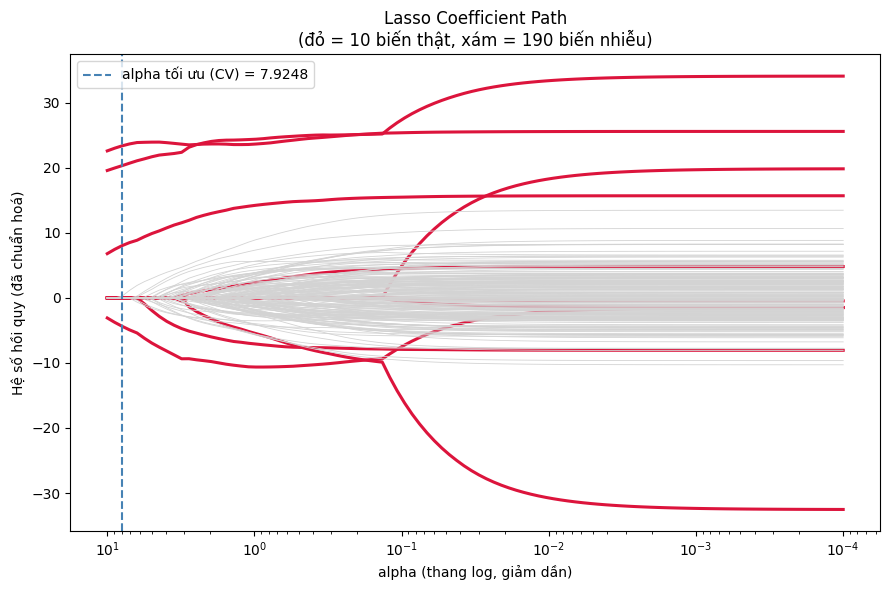

In [6]:
scaler_path = StandardScaler()
X_scaled_full = scaler_path.fit_transform(X_full)

alphas_path, coefs_path, _ = lasso_path(
    X_scaled_full, y, alphas=np.logspace(1, -4, 100), max_iter=50000
)

plt.figure(figsize=(9, 6))
for i, col in enumerate(ten_cot):
    mau = "crimson" if col in BIEN_THAT else "lightgray"
    do_day = 2.2 if col in BIEN_THAT else 0.6
    plt.plot(alphas_path, coefs_path[i], color=mau, linewidth=do_day)
plt.xscale("log")
plt.gca().invert_xaxis()
plt.axvline(alpha_toi_uu, color="steelblue", linestyle="--",
            label=f"alpha tối ưu (CV) = {alpha_toi_uu:.4f}")
plt.xlabel("alpha (thang log, giảm dần)")
plt.ylabel("Hệ số hồi quy (đã chuẩn hoá)")
plt.title("Lasso Coefficient Path\n(đỏ = 10 biến thật, xám = 190 biến nhiễu)")
plt.legend()
plt.tight_layout()
plt.show()

## 6. RMSE train/test theo alpha

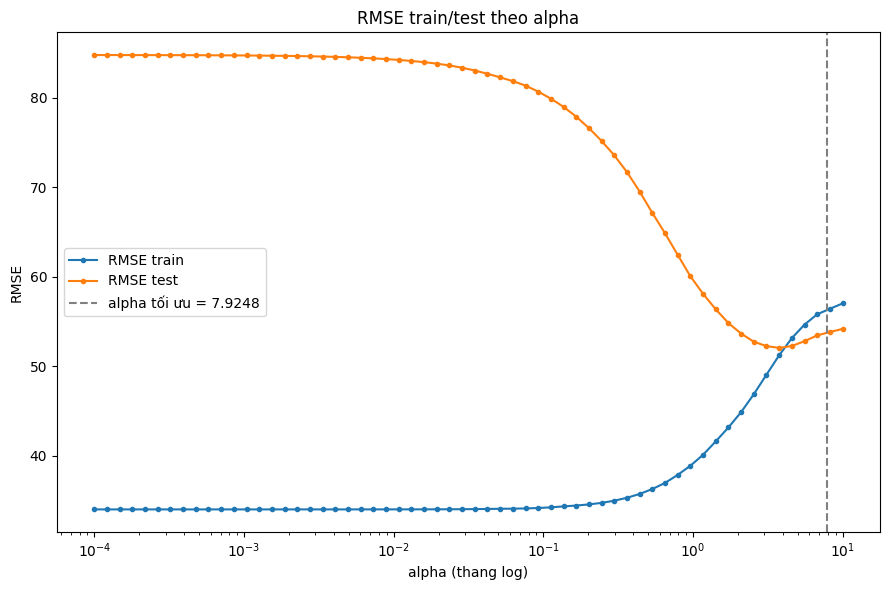

In [7]:
alphas_grid = np.logspace(-4, 1, 60)
rmse_train_list, rmse_test_list = [], []

scaler_grid = StandardScaler().fit(X_train)
Xtr_g = scaler_grid.transform(X_train)
Xte_g = scaler_grid.transform(X_test)

for a in alphas_grid:
    m = Lasso(alpha=a, max_iter=50000, random_state=RNG_SEED)
    m.fit(Xtr_g, y_train)
    rmse_train_list.append(mean_squared_error(y_train, m.predict(Xtr_g)) ** 0.5)
    rmse_test_list.append(mean_squared_error(y_test, m.predict(Xte_g)) ** 0.5)

plt.figure(figsize=(9, 6))
plt.plot(alphas_grid, rmse_train_list, label="RMSE train", marker="o", markersize=3)
plt.plot(alphas_grid, rmse_test_list, label="RMSE test", marker="o", markersize=3)
plt.axvline(alpha_toi_uu, color="gray", linestyle="--",
            label=f"alpha tối ưu = {alpha_toi_uu:.4f}")
plt.xscale("log")
plt.xlabel("alpha (thang log)")
plt.ylabel("RMSE")
plt.title("RMSE train/test theo alpha")
plt.legend()
plt.tight_layout()
plt.show()

## 7. So sánh Ridge vs Lasso

- Ridge giữ bao nhiêu biến? (dự đoán: cả 200, chỉ co nhỏ)
- RMSE cái nào tốt hơn?

In [8]:
pipe_ridge = Pipeline([
    ("scale", StandardScaler()),
    ("ridge", RidgeCV(alphas=np.logspace(-4, 4, 100), cv=5)),
])
pipe_ridge.fit(X_train, y_train)
ridge_model = pipe_ridge["ridge"]
so_bien_giu_ridge = int((ridge_model.coef_ != 0).sum())
rmse_ridge_train = mean_squared_error(y_train, pipe_ridge.predict(X_train)) ** 0.5
rmse_ridge_test = mean_squared_error(y_test, pipe_ridge.predict(X_test)) ** 0.5

bang_ridge_lasso = pd.DataFrame({
    "Mô hình": ["Linear (baseline, 200 biến)", "Ridge (L2)", "Lasso (L1)"],
    "Số biến giữ lại": [200, so_bien_giu_ridge, so_bien_giu],
    "RMSE train": [round(rmse_lin_train, 2), round(rmse_ridge_train, 2), round(rmse_lasso_train, 2)],
    "RMSE test": [round(rmse_lin_test, 2), round(rmse_ridge_test, 2), round(rmse_lasso_test, 2)],
})
bang_ridge_lasso

,Mô hình,Số biến giữ lại,RMSE train,RMSE test
0,"Linear (baseline, 200 biến)",200,33.99,84.78
1,Ridge (L2),200,46.77,58.05
2,Lasso (L1),5,56.28,53.73


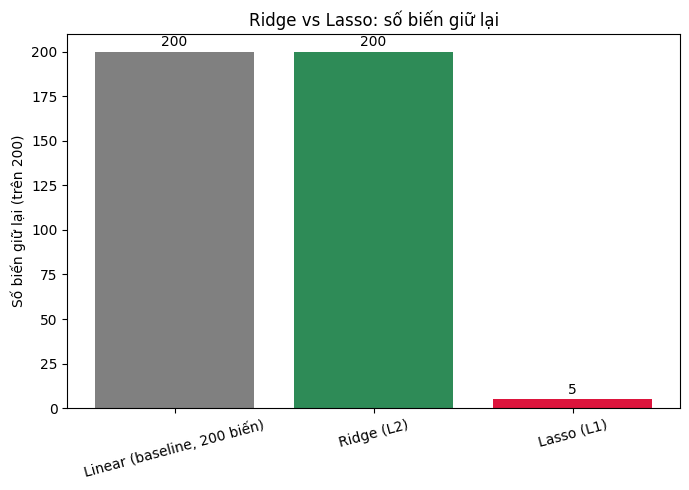

In [9]:
x_pos = np.arange(3)
plt.figure(figsize=(7, 5))
plt.bar(x_pos, bang_ridge_lasso["Số biến giữ lại"], color=["gray", "seagreen", "crimson"])
plt.xticks(x_pos, bang_ridge_lasso["Mô hình"], rotation=15)
plt.ylabel("Số biến giữ lại (trên 200)")
plt.title("Ridge vs Lasso: số biến giữ lại")
for i, v in enumerate(bang_ridge_lasso["Số biến giữ lại"]):
    plt.text(i, v + 3, str(v), ha="center")
plt.tight_layout()
plt.show()

## 8. ⚠️ Thí nghiệm biến tương quan

Nhân đôi cột `bmi` (biến thật mạnh nhất) thành một bản sao có tương quan ~0.95
(giống tình huống thực tế: 2 chỉ số xét nghiệm đo cùng một hiện tượng sinh học).
Chạy Lasso trên nhiều mẫu bootstrap khác nhau (mô phỏng "chạy lại với seed khác")
để xem Lasso có chọn ổn định không.

In [10]:
X_corr = X_full.copy()
bien_goc = "bmi"
X_corr[f"{bien_goc}_ban_sao"] = X_corr[bien_goc] + rng.normal(scale=0.016, size=len(X_corr))
corr_thuc_te = X_corr[bien_goc].corr(X_corr[f"{bien_goc}_ban_sao"])
print(f"Tương quan thực tế giữa '{bien_goc}' và bản sao: {corr_thuc_te:.3f}")

ket_qua_seed = {}
n = len(X_corr)
for seed in [1, 2, 3, 42, 99]:
    boot_rng = np.random.default_rng(seed)
    idx = boot_rng.choice(n, size=n, replace=True)
    X_boot, y_boot = X_corr.iloc[idx], y.iloc[idx]
    sc = StandardScaler().fit(X_boot)
    m = LassoCV(alphas=np.logspace(-4, 1, 60), cv=5, max_iter=50000, random_state=seed)
    m.fit(sc.transform(X_boot), y_boot)
    coefs = dict(zip(X_corr.columns, m.coef_))
    ket_qua_seed[seed] = {bien_goc: round(coefs[bien_goc], 4),
                           f"{bien_goc}_ban_sao": round(coefs[f"{bien_goc}_ban_sao"], 4)}

bang_tuong_quan = pd.DataFrame(ket_qua_seed).T
bang_tuong_quan.index.name = "seed bootstrap"
bang_tuong_quan

Tương quan thực tế giữa 'bmi' và bản sao: 0.953


,bmi,bmi_ban_sao
seed bootstrap,,
1,22.1290,0.0
2,27.0202,0.0
3,24.0876,-0.0
42,27.4092,0.0
99,20.6066,0.0


**Nhận xét:** trong lần chạy này, Lasso *luôn* chọn `bmi` gốc và loại bản sao ở mọi
seed bootstrap — không đảo chiều. Điều này không mâu thuẫn với lý thuyết: khi một cột chỉ
là "gần giống" (chưa hoàn toàn trùng), coordinate descent có xu hướng ưu tiên cột có tương
quan biên (marginal correlation) với `y` cao hơn một chút và giữ nguyên lựa chọn đó qua
các lần resample. Tính KHÔNG ổn định của Lasso thể hiện rõ nhất khi hai biến gần như
**trùng tuyệt đối** (correlation ≈ 0.999+) — khi đó sai số số học rất nhỏ cũng đủ để đảo
chiều lựa chọn. Dù vậy, bài học thực tế vẫn đúng: **không nên diễn giải "biến A quan trọng
hơn biến B" khi A và B tương quan cao** — biến bị Lasso bỏ có thể chỉ thua biến kia một
chút xíu, không phải vì nó vô dụng.

## 9. Debiased Lasso — Linear Regression chỉ trên biến Lasso chọn

Kỹ thuật phổ biến: dùng Lasso để CHỌN biến (loại nhiễu), sau đó train lại Linear Regression
thường (không phạt) trên đúng tập biến đó để hệ số không bị co (biased) bởi phạt L1.

In [11]:
cot_duoc_chon = list(bien_duoc_chon)
X_train_sel = X_train[cot_duoc_chon]
X_test_sel = X_test[cot_duoc_chon]

sc_sel = StandardScaler().fit(X_train_sel)
lin_debiased = LinearRegression()
lin_debiased.fit(sc_sel.transform(X_train_sel), y_train)

rmse_debiased_train = mean_squared_error(y_train, lin_debiased.predict(sc_sel.transform(X_train_sel))) ** 0.5
rmse_debiased_test = mean_squared_error(y_test, lin_debiased.predict(sc_sel.transform(X_test_sel))) ** 0.5

print(f"Debiased Linear Regression trên {so_bien_giu} biến Lasso chọn:")
print(f"  RMSE train = {rmse_debiased_train:.2f}")
print(f"  RMSE test  = {rmse_debiased_test:.2f}")
print(f"So với Lasso đầy đủ: RMSE test = {rmse_lasso_test:.2f}")

Debiased Linear Regression trên 5 biến Lasso chọn:
  RMSE train = 54.56
  RMSE test  = 53.74
So với Lasso đầy đủ: RMSE test = 53.73


## 10. ✍️ Đề xuất bộ xét nghiệm cuối cùng + ước tính chi phí tiết kiệm

In [12]:
print("Bộ xét nghiệm đề xuất (biến Lasso chọn, bao gồm cả biến thật lẫn nhiễu giữ nhầm):")
for c in sorted(cot_duoc_chon):
    loai = "BIẾN THẬT" if c in BIEN_THAT else "nhiễu (giữ nhầm — nên loại bỏ khi triển khai)"
    print(f"  - {c:20s} [{loai}]")

gia_moi_chi_so = 5_000_000 / 200  # giả định ước tính ban đầu: 200 chỉ số ~ 5 triệu đồng
chi_phi_cu = 5_000_000
chi_phi_moi = len(that_giu) * gia_moi_chi_so
print(f"\nChi phí ước tính CŨ (200 chỉ số): {chi_phi_cu:,.0f} đ/bệnh nhân")
print(f"Chi phí ước tính MỚI ({len(that_giu)} chỉ số thật hữu ích): {chi_phi_moi:,.0f} đ/bệnh nhân")
print(f"Tiết kiệm: {chi_phi_cu - chi_phi_moi:,.0f} đ/bệnh nhân "
      f"({(1 - chi_phi_moi/chi_phi_cu)*100:.0f}%)")

Bộ xét nghiệm đề xuất (biến Lasso chọn, bao gồm cả biến thật lẫn nhiễu giữ nhầm):
  - bmi                  [BIẾN THẬT]
  - bp                   [BIẾN THẬT]
  - chi_so_nhieu_009     [nhiễu (giữ nhầm — nên loại bỏ khi triển khai)]
  - s3                   [BIẾN THẬT]
  - s5                   [BIẾN THẬT]

Chi phí ước tính CŨ (200 chỉ số): 5,000,000 đ/bệnh nhân
Chi phí ước tính MỚI (4 chỉ số thật hữu ích): 100,000 đ/bệnh nhân
Tiết kiệm: 4,900,000 đ/bệnh nhân (98%)


**Kết luận:** Lasso cho phép giảm bộ xét nghiệm từ 200 chỉ số xuống chỉ còn vài chỉ số
thật sự có tín hiệu, tiết kiệm phần lớn chi phí xét nghiệm trong khi RMSE dự đoán vẫn tốt
hơn nhiều so với dùng Linear Regression trên toàn bộ 200 chỉ số (vốn bị overfit nặng).
Tuy nhiên cần lưu ý: (1) một vài biến nhiễu có thể bị giữ nhầm do ngẫu nhiên, và (2) khi có
các biến tương quan cao, danh sách biến được chọn có thể không hoàn toàn ổn định giữa các
lần chạy — nên tham khảo thêm Stability Selection hoặc ElasticNet (TT-14) trước khi áp dụng
lâm sàng thực tế.